In [2]:
# Import our libraries 
# Pandas and numpy for data wrangling
import pandas as pd
import numpy as np

# Seaborn / matplotlib for visualization 
import seaborn as sns
import matplotlib.pyplot as plt

# Import the trees from sklearn
from sklearn import tree

# Helper function to split our data
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Helper fuctions to evaluate our model.
from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

from sklearn.impute import SimpleImputer

# Import our Decision Tree
from sklearn.preprocessing import StandardScaler

# Import our Random Forest 
from sklearn.pipeline import Pipeline

# Use inline so our visualizations display in notebook
%matplotlib inline

## Main Steps when building a Machine Learning Model. 
1. Inspect and explore data.
2. Select and engineer features.
3. Build and train model.
4. Evaluate model.

# #1 Inspect and explore data.
* Load titanic data
* Visualize all the data using sns.pairplot
* Check for null values

In [3]:
# Load in the titanic data set.
df = pd.read_csv('/Users/test/ds-fall-2025-tue/Week-09-Trees/data/titanic.csv')

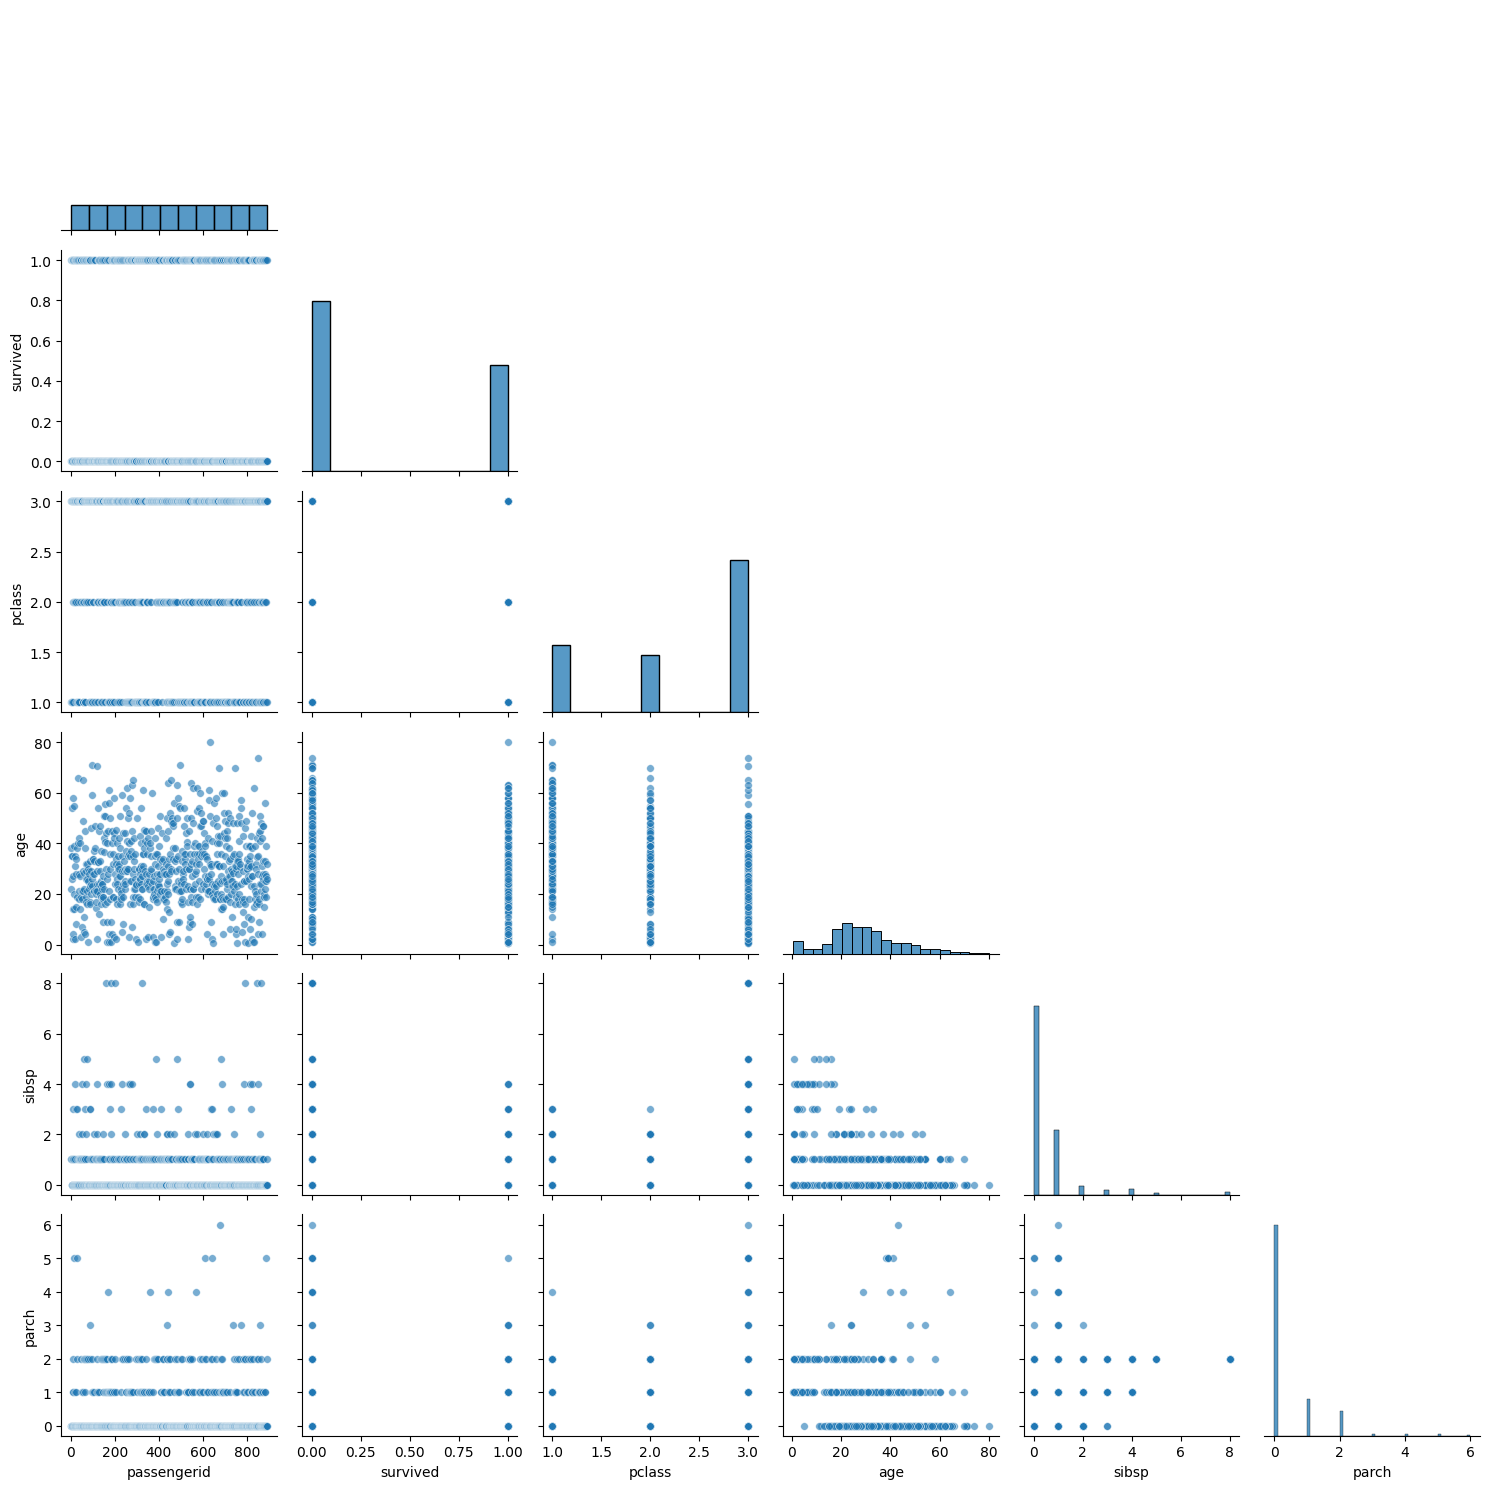

In [4]:
# Visualize all the data using sns.pairplot
if 'Survived' in df.columns:
    df['Survived'] = df['Survived'].astype('category')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
subset = num_cols[:6] if len(num_cols) > 6 else num_cols
plot_df = df[subset + (['Survived'] if 'Survived' in df.columns else [])]

plot_kwargs = dict(corner=True, diag_kind='hist', plot_kws={'alpha': 0.6, 's': 30})
if 'Survived' in plot_df.columns:
    plot_kwargs['hue'] = 'Survived'

sns.pairplot(plot_df, **plot_kwargs)
plt.tight_layout()
plt.show()


,null_count,null_percent
cabin,687,77.104377
age,177,19.865320
embarked,2,0.224467


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


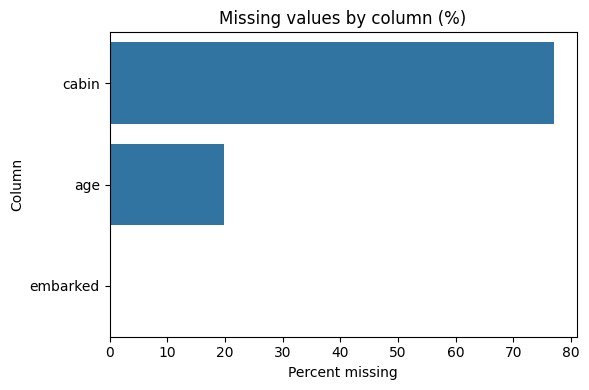

In [5]:
# Check for null values
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_summary = pd.DataFrame({'null_count': null_counts, 'null_percent': null_percent})
missing_cols = null_summary[null_summary['null_count'] > 0].sort_values('null_count', ascending=False)

if missing_cols.empty:
    print("No missing values found.")
else:
    display(missing_cols)
    # show a few rows that contain any missing values
    display(df[df.isnull().any(axis=1)].head())

    # quick visualization of missingness by percent
    plt.figure(figsize=(6, max(4, 0.4 * len(missing_cols))))
    sns.barplot(x='null_percent', y=missing_cols.index, data=missing_cols.reset_index(drop=False).rename(columns={'index':'col'}))
    plt.xlabel('Percent missing')
    plt.ylabel('Column')
    plt.title('Missing values by column (%)')
    plt.tight_layout()
    plt.show()

# #2 Select and engineer features.
1. Fill age null values with -999
1. Convert to numerical values if need be by using `pd.get_dummies()`
1. Create a list of the features you are going to use.  In this case use as many or as little as you would like.
1. Define our `X` and `y`
1. Split our data into trainig and testing sets.

In [6]:
# Fill age null values with -999
if 'age' in df.columns:
    df['age'] = df['age'].fillna(-999)
else:
    print("Column 'Age' not found in df")

In [7]:
# 1. Convert to numerical values if need be by using `pd.get_dummies()`
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

# don't one-hot encode the target if present
target = 'Survived' if 'Survived' in df.columns else ('survived' if 'survived' in df.columns else None)
if target and target in cat_cols:
    cat_cols.remove(target)

if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print(f"One-hot encoded columns: {cat_cols}")
else:
    print("No categorical columns to encode.")

One-hot encoded columns: ['name', 'sex', 'ticket', 'cabin', 'embarked']


In [8]:
# 2. Create a list of the features we are going to use.
target = 'Survived' if 'Survived' in df.columns else ('survived' if 'survived' in df.columns else None)
exclude = {col for col in [target, 'PassengerId', 'Name', 'Ticket', 'Cabin'] if col is not None}

# candidate features (prefer numeric ones after one-hot encoding)
candidate_features = [c for c in df.columns if c not in exclude]
numeric_features = [c for c in candidate_features if np.issubdtype(df[c].dtype, np.number)]

if numeric_features:
    selected_features = numeric_features
else:
    # fallback to first few non-target columns
    selected_features = candidate_features[:6]

print("selected_features:", selected_features)


selected_features: ['passengerid', 'pclass', 'age', 'sibsp', 'parch', 'fare']


In [9]:
# Define our `X` and `y`
target = 'Survived' if 'Survived' in df.columns else ('survived' if 'survived' in df.columns else None)
if target is None:
    raise ValueError("Target column 'Survived' or 'survived' not found in df")

# Ensure selected_features exists
if 'selected_features' not in globals():
    # fallback: select numeric columns excluding target
    selected_features = [c for c in df.columns if c != target and np.issubdtype(df[c].dtype, np.number)]
    selected_features = selected_features[:6] if len(selected_features) > 6 else selected_features

X = df[selected_features].copy()
y = df[target].copy()

# Convert categorical/object target to numeric codes if needed
if pd.api.types.is_categorical_dtype(y):
    y = y.cat.codes
elif y.dtype == object:
    y, _ = pd.factorize(y)

print("X.shape =", X.shape, "y.shape =", y.shape)
display(X.head())
display(y.value_counts())


X.shape = (891, 6) y.shape = (891,)


/var/folders/b2/rycdlzl16h5fb0d7bk5l_jv80000gp/T/ipykernel_11281/2385166118.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(y):


,passengerid,pclass,age,sibsp,parch,fare
0,1,3,22.0,1,0,7.2500
1,2,1,38.0,1,0,71.2833
2,3,3,26.0,0,0,7.9250
3,4,1,35.0,1,0,53.1000
4,5,3,35.0,0,0,8.0500


survived
0    549
1    342
Name: count, dtype: int64

In [10]:
# Split our data into trainig and testing sets.
if len(np.unique(y)) > 1:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Length of our Training data:', len(X_train), '\nLength of our Testing data:', len(X_test))

Length of our Training data: 712 
Length of our Testing data: 179


# #3 Build and train model.
1. For our first pass, initialize our model with `max_depth=2`.
2. Fit our model with our training data. 
3. Make predictions of our testing data. 
4. Evaluate and print our model scores using accuracy, precision, recall, f1 scores, and auc scores. 
    * To calculate auc score you have to get the predicted probabilites for the Survived class using `model.predict_proba(X_test)[:,1]`
5. Visualize our Decision Tree using provided code. 


In [11]:
# For our first pass, initialize our model with `max_depth=2`.

model = tree.DecisionTreeClassifier(max_depth=2, random_state=42)

In [12]:
# Fit our model with our training data. 
model.fit(X_train, y_train)
print("Model trained. Train score: %.4f" % model.score(X_train, y_train))


Model trained. Train score: 0.7022


In [13]:
# Make predictions of our testing data. 
from sklearn.exceptions import NotFittedError

# Make predictions of our testing data.
try:
    y_pred = model.predict(X_test)
except NotFittedError:
    # model wasn't fitted (e.g. kernel restarted) — fit then predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

print("Predictions shape:", y_pred.shape)
print("Test Accuracy: %.4f" % accuracy_score(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


Predictions shape: (179,)
Test Accuracy: 0.6425

Classification report:
              precision    recall  f1-score   support

           0       0.65      0.90      0.76       110
           1       0.59      0.23      0.33        69

    accuracy                           0.64       179
   macro avg       0.62      0.57      0.54       179
weighted avg       0.63      0.64      0.59       179


Confusion matrix:
[[99 11]
 [53 16]]


In [14]:
# 4. Evaluate and print our model scores using accuracy, precision, recall, f1 scores, and auc scores. 
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_test, y_pred, zero_division=0)
print("Precision Score: %f" % precision)

recall = recall_score(y_test, y_pred, zero_division=0)
print("Recall Score: %f" % recall)

f1 = f1_score(y_test, y_pred, zero_division=0)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities
y_pred_proba = model.predict_proba(X_test)

# Keep only the proba for True
y_pred_proba = y_pred_proba[:,1]

# Compute auc score
auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)

Accuracy Score: 0.642458
Precision Score: 0.592593
Recall Score: 0.231884
F1 Score: 0.333333
AUC Score: 0.675494


# Visualize your tree

# Picking the right parameters...

# Parameter tuning of your Decision Tree using GridSearch or RandomizedSearch

### For assistance on this, look at Steves TA Tips code in `TA-Tips/random_forest_tuning.ipynb`


1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
1. Initalize your GridSearchCV with a DecisionTreeClassifier, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
1. Fit your GridSearchCV with your training data. 
1. Print the parameters of your best model. 
1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 
1. Visualize your best tree.
1. Which feature was your most important feature?

```python
tree.DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_impurity_split=None,
    class_weight=None,
    presort='deprecated',
    ccp_alpha=0.0,
)
```


[Tips on how to customize / set the paramters in the decision tree.](https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use)

In [15]:
# 1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search.from sklearn.model_selection import GridSearchCV
params = { 
    'PARAMETER_NAME': ['LIST', 'OF', 'VALUES'], ??? }

SyntaxError: invalid syntax (1119414045.py, line 3)

In [ ]:
# 1. Initalize your GridSearchCV with a DecisionTreeClassifier, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
grid_search_cv =  GridSearchCV( ??? )

In [ ]:
# 1. Fit your GridSearchCV with your training data. 


In [ ]:
# 1. Print the parameters of your best model. 
# Print the best parameters it found
print( ??? )

In [ ]:
# 1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 

# This command gives you the best tree
model = ???

# Now lets evaluate our model
y_pred = ???

accuracy = ???
print("Accuracy Score: %f" % accuracy)

precision = ???
print("Precision Score: %f" % precision)

recall = ???
print("Recall Score: %f" % recall)

f1 = ???
print('F1 Score: %f' % f1)

# Calculate predicted probabilities, keep only probability for when class = 1
y_pred_proba = model.predict_proba(???)[:,1]
auc = ???
print('AUC Score: %f' % auc)

In [ ]:
# 1. Which feature was your most important feature?
# Now lets look at our feature importances
feature_imp = pd.DataFrame.from_dict( {'feature_importance': model.feature_importances_,
                                       'feature':selected_features }).sort_values('feature_importance', ascending=False)
feature_imp

# Now onto Random Forests...
Were going to do the same with, but this time with a random forest. Remeber... Repetition is the father of learning.

1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
1. Initalize your GridSearchCV with a RandomForestClassifer, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
1. Fit your GridSearchCV with your training data. 
1. Print the parameters of your best model. 
1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 
1. Which feature was your most important feature?


# Parameters of the Random Forest Classifier

```python
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='auto',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_impurity_split=None,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
)
```

In [ ]:
# 1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
params = {
    'max_depth': [None, 2, 4, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

In [ ]:
# 1. Initalize your GridSearchCV or RandomizedSearchCV with a RandomForestClassifer, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 4, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf = RandomForestClassifier(random_state=42)

grid_search_cv = GridSearchCV(
    estimator=rf,
    param_grid=params,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit the grid search
grid_search_cv.fit(X_train, y_train)

# Print best params and set best model
print("Best params:", grid_search_cv.best_params_)
model = grid_search_cv.best_estimator_

# Quick evaluation
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_pred_proba))


Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_dep

In [ ]:
# 1. Fit your GridSearchCV with your training data. 
try:
    grid_search_cv.fit(X_train, y_train)
except Exception as e:
    print("GridSearchCV failed:", e)
else:
    print("GridSearchCV completed.")
    print("Best params:", grid_search_cv.best_params_)
    # set best model
    model = grid_search_cv.best_estimator_
    # quick evaluation
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("Test AUC:", roc_auc_score(y_test, y_pred_proba))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_dep

In [ ]:
# 1. Print the parameters of your best model. 
# Print the best parameters it found
print(grid_search_cv.best_params_)
print("Best CV score (scoring='roc_auc'):", grid_search_cv.best_score_)




{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score (scoring='roc_auc'): 0.7917391258457089


In [ ]:
# 1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 

# This command gives you tree that has the highest f1-score. 
model = grid_search_cv.best_estimator_

# Now lets evaluate our model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_test, y_pred, zero_division=0)
print("Precision Score: %f" % precision)

recall = recall_score(y_test, y_pred, zero_division=0)
print("Recall Score: %f" % recall)

f1 = f1_score(y_test, y_pred, zero_division=0)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities, keep only probability for when class = 1
y_pred_proba = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)

Accuracy Score: 0.675978
Precision Score: 0.603774
Recall Score: 0.463768
F1 Score: 0.524590
AUC Score: 0.711265


In [ ]:
# 1. Which feature was your most important feature?
# Now lets look at our feature importances
feature_imp = pd.Series(model.feature_importances_,index=selected_features).sort_values(ascending=False)
feature_imp

fare           0.337116
passengerid    0.211925
age            0.188025
pclass         0.131784
parch          0.069320
sibsp          0.061830
dtype: float64

# Build a random forest using the ny-vs-sf-housing.csv data. 
* Your target variable, aka the column you are trying to predict, aka your `y` variable is `in_sf`. 
* Can you get an accuracy above %88.8889?
* What was your most important feature?


In [ ]:
df = pd.read_csv('/Users/test/ds-fall-2025-tue/Week-09-Trees/data/ny-vs-sf-houses.csv')
df.head()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
0,0,2.0,1.0,999000,1960,1000,999,10
1,0,2.0,2.0,2750000,2006,1418,1939,0
2,0,2.0,2.0,1350000,1900,2150,628,9
3,0,1.0,1.0,629000,1903,500,1258,9
4,0,0.0,1.0,439000,1930,500,878,10


In [18]:
# ...existing code...
# Ensure df with 'in_sf' is loaded
target = 'in_sf'
if target not in df.columns:
    df = pd.read_csv('/Users/test/ds-fall-2025-tue/Week-09-Trees/data/ny-vs-sf-houses.csv')
    if target not in df.columns:
        raise KeyError(f"Target column '{target}' not found after loading ny-vs-sf-houses.csv")

exclude = {target}
selected_features = [c for c in df.columns if c not in exclude and np.issubdtype(df[c].dtype, np.number)]

X = df[selected_features].copy()
y = df[target].copy()

# Split data (only stratify if >1 class)
strat = y if len(np.unique(y)) > 1 else None
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=strat)

# Impute numeric missing values
imp = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imp.transform(X_test), columns=X_test.columns, index=X_test.index)

# Initialize and train model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy: %.4f" % accuracy)
print("Precision: %.4f" % precision)
print("Recall: %.4f" % recall)
print("F1: %.4f" % f1)

# AUC for binary target
if len(np.unique(y)) == 2:
    y_proba = model.predict_proba(X_test)[:, 1]
    print("AUC: %.4f" % roc_auc_score(y_test, y_proba))

# Feature importances
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop features:\n", feat_imp.head(10))
# ...existing code...

Accuracy: 0.8990
Precision: 0.8929
Recall: 0.9259
F1: 0.9091
AUC: 0.9665

Top features:
 elevation         0.334038
price_per_sqft    0.249403
sqft              0.114077
price             0.110350
year_built        0.104812
beds              0.056183
bath              0.031137
dtype: float64


# Awesome difficult extra credit below:
Build a classifier using the adult_income.csv data.  
* The target variable is 'class'
* Start with just using these features `selected_features = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']`
* You have to include the pos_label in your precision, recall, and f1 scores. It just tells the classifier which one is the posotive label.  I provided the proper way below.

* See if you can get above 50% f1 score.  
* See some [super tricks and tips here](https://www.kaggle.com/code/jieyima/income-classification-model)

In [ ]:
df = pd.read_csv('/Users/test/ds-fall-2025-tue/Week-09-Trees/data/adult_income.csv')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [24]:
# python
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

DATA_DIR = os.path.join('Week-09-Trees', 'data')

def _prepare_and_train(df, feature_cols, target_col, random_state=42):
    assert target_col in df.columns, f"Target column '{target_col}' not found in dataframe."
    missing = [c for c in feature_cols if c not in df.columns]
    assert not missing, f"Missing features in dataframe: {missing}"
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # Encode target if necessary
    if y.dtype == object or y.dtype.name == 'category':
        y_fact, uniques = pd.factorize(y)
        y = y_fact
    else:
        y = y.values

    strat = y if len(np.unique(y)) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=strat)

    imp = SimpleImputer(strategy='mean')
    X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(imp.transform(X_test), columns=X_test.columns, index=X_test.index)

    model = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    proba = None
    if hasattr(model, 'predict_proba') and len(np.unique(y)) == 2:
        try:
            proba = model.predict_proba(X_test)[:, 1]
        except Exception:
            proba = None

    return {
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_proba': proba,
        'X_train_shape': X_train.shape
    }

def _choose_pos_label(orig_series, y_train_encoded):
    # If binary numeric 0/1, pick 1
    unique_train = np.unique(y_train_encoded)
    if unique_train.size == 2 and set(unique_train.tolist()) <= {0, 1}:
        return 1
    # Try to detect high-income label if original series provided
    if orig_series is not None:
        for lab in pd.Series(orig_series).unique():
            s = str(lab).lower()
            if ('>50' in s) or ('50k' in s) or ('high' in s) or ('> 50' in s):
                # map to factor index if factorized
                try:
                    idx = list(pd.factorize(orig_series)[1]).index(lab)
                    return idx
                except Exception:
                    continue
    # Fallback to the largest label
    return int(unique_train[-1])

def test_adult_income_f1_threshold():
    path = os.path.join(DATA_DIR, '/Users/test/ds-fall-2025-tue/Week-09-Trees/data/adult_income.csv')
    assert os.path.exists(path), f"adult_income.csv not found at {path}"
    df = pd.read_csv(path)
    assert 'class' in df.columns, "Target 'class' missing from adult_income.csv"

    selected_features = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
    res = _prepare_and_train(df, selected_features, 'class', random_state=42)

    # determine pos_label using original df['class'] and encoded y_train
    # Reconstruct encoded y_train to pass to chooser
    y = df['class']
    # encode same way as _prepare_and_train
    if y.dtype == object or y.dtype.name == 'category':
        y_enc, _ = pd.factorize(y)
    else:
        y_enc = y.values
    pos_label = _choose_pos_label(df['class'], y_enc)

    precision = precision_score(res['y_test'], res['y_pred'], pos_label=pos_label, zero_division=0)
    recall = recall_score(res['y_test'], res['y_pred'], pos_label=pos_label, zero_division=0)
    f1 = f1_score(res['y_test'], res['y_pred'], pos_label=pos_label, zero_division=0)
    accuracy = accuracy_score(res['y_test'], res['y_pred'])

    summary = f"adult_income: acc={accuracy:.4f}, prec={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}"
    print(summary)
    assert f1 >= 0.50, f"F1 below threshold for adult_income: {f1:.4f}. Summary: {summary}"

def test_ny_vs_sf_accuracy_threshold():
    path = os.path.join(DATA_DIR, '/Users/test/ds-fall-2025-tue/Week-09-Trees/data/ny-vs-sf-houses.csv')
    assert os.path.exists(path), f"ny-vs-sf-houses.csv not found at {path}"
    df = pd.read_csv(path)
    assert 'in_sf' in df.columns, "Target 'in_sf' missing from ny-vs-sf-houses.csv"

    # select numeric features excluding target
    numeric_features = [c for c in df.columns if c != 'in_sf' and np.issubdtype(df[c].dtype, np.number)]
    assert numeric_features, "No numeric features found in ny-vs-sf-houses.csv to train on."

    res = _prepare_and_train(df, numeric_features, 'in_sf', random_state=42)

    accuracy = accuracy_score(res['y_test'], res['y_pred'])
    precision = precision_score(res['y_test'], res['y_pred'], zero_division=0)
    recall = recall_score(res['y_test'], res['y_pred'], zero_division=0)
    f1 = f1_score(res['y_test'], res['y_pred'], zero_division=0)

    summary = f"ny-vs-sf: acc={accuracy:.6f}, prec={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}"
    print(summary)
    # target threshold from notebook prompt: 88.8889% accuracy
    assert accuracy >= 0.888889, f"Accuracy below 88.8889% for ny-vs-sf: {accuracy:.6f}. Summary: {summary}"

if __name__ == "__main__":
    # allow running as a script for quick checks
    try:
        test_adult_income_f1_threshold()
        test_ny_vs_sf_accuracy_threshold()
        print("All tests executed (script mode).")
    except AssertionError as e:
        print("Test failure:", e)
        raise

adult_income: acc=0.7769, prec=0.5427, recall=0.4662, f1=0.5015
ny-vs-sf: acc=0.898990, prec=0.8929, recall=0.9259, f1=0.9091
All tests executed (script mode).
